times           = [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35] ...
tls_pop         = [1.         0.9508278  0.9040735  0.85961822 0.81734889 0.77715805
 0.73894348 0.702608  ] ...
flux_left       = [0.         0.5        0.24369855 0.15833709 0.11571055 0.09017792
 0.07319214 0.06109021] ...
flux_right      = [0.         0.5        0.24369855 0.15833709 0.11571055 0.09017792
 0.07319214 0.06109021] ...
total_quanta    = [1.         1.9508278  2.39147059 2.66368948 2.85284126 2.99300625
 3.10117596 3.1870209 ] ...


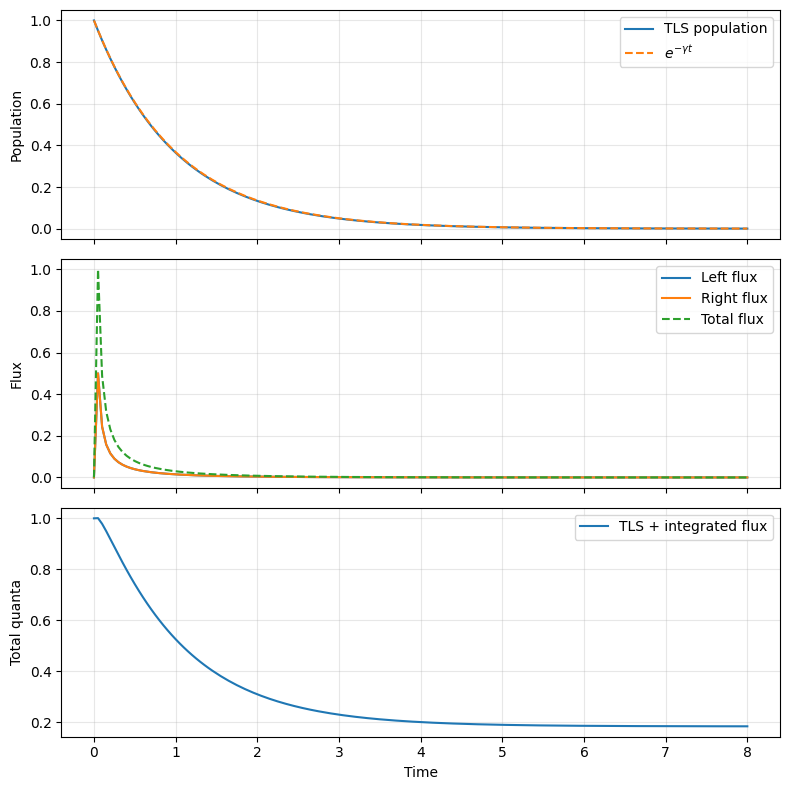

In [ ]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
import wqedlib as qmps

# ============================================================
# Standard observable helper
# ============================================================


def compute_standard_observables(bins: qmps.BinsSeemps, params):
    """
    Standard observables for Markovian time-bin evolution.

    Notes
    -----
    - tls_pop is evaluated on system_states and is indexed by bins.times
    - photon_bins_l/r are the average photon numbers in each emitted time bin
      (not continuous-time fluxes)
    - therefore cumulative emitted quanta are obtained by direct cumulative sum,
      without an extra factor of delta_t
    """
    tls_pop_op = qmps.tls_pop()
    b_pop_l = qmps.num_op_l(params.d_t_total)
    b_pop_r = qmps.num_op_r(params.d_t_total)

    tls_pop = qmps.single_time_expectation(bins.system_states, tls_pop_op)

    photon_bins = qmps.single_time_expectation(
        bins.output_field_states, [b_pop_l, b_pop_r]
    )

    photon_bins_l = np.asarray(photon_bins[0], float)
    photon_bins_r = np.asarray(photon_bins[1], float)

    emitted_l = np.cumsum(photon_bins_l)
    emitted_r = np.cumsum(photon_bins_r)

    # align with system times: at t=0 no emitted bin yet
    emitted_l_full = np.concatenate([[0.0], emitted_l])
    emitted_r_full = np.concatenate([[0.0], emitted_r])

    total_quanta = np.asarray(tls_pop, float) + emitted_l_full + emitted_r_full

    return {
        "tls_pop": np.asarray(tls_pop, float),
        "photon_bins_l": photon_bins_l,
        "photon_bins_r": photon_bins_r,
        "emitted_l": emitted_l_full,
        "emitted_r": emitted_r_full,
        "total_quanta": total_quanta,
    }


# ============================================================
# Plot helper
# ============================================================


def plot_standard_observables(bins: qmps.BinsSeemps, params):
    obs = compute_standard_observables(bins, params)

    t = bins.times
    t_bins = bins.times[1:]  # emitted bins appear after each evolution step

    gamma_total = params.gamma_l + params.gamma_r

    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=False)

    axes[0].plot(t, obs["tls_pop"], label="TLS population")
    axes[0].plot(t, np.exp(-gamma_total * t), "--", label=rf"$e^{{-\gamma t}}$")
    axes[0].set_ylabel("Population")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(t_bins, obs["photon_bins_l"], label="Left bin population")
    axes[1].plot(t_bins, obs["photon_bins_r"], label="Right bin population")
    axes[1].plot(
        t_bins,
        obs["photon_bins_l"] + obs["photon_bins_r"],
        "--",
        label="Total bin population",
    )
    axes[1].set_ylabel("Bin photon number")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, obs["total_quanta"], label="TLS + emitted photons")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Total quanta")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# Example
# ============================================================

if __name__ == "__main__":
    params = qmps.parameters.InputParams(
        delta_t=0.05,
        tmax=8,
        d_sys_total=np.array([2], dtype=int),
        d_t_total=np.array([2, 2], dtype=int),
        gamma_l=0.5,
        gamma_r=0.5,
        bond_max=18,
    )

    # local initial states only
    i_s0 = qmps.tls_excited()
    i_n0 = qmps.wg_ground(int(np.prod(params.d_t_total)))

    # local collision Hamiltonian from your library
    hm = qmps.atom_waveguide_markov_hamiltonian_lr(params)

    # evolve -> only bins
    bins = qmps.t_evol_mar_seemps_lr(hm, i_s0, i_n0, params, store_mps=True)

    # choose observables later, exactly Qwave style
    tls_pop_op = qmps.tls_pop()
    b_pop_l = qmps.num_op_l(params.d_t_total)
    b_pop_r = qmps.num_op_r(params.d_t_total)

    tls_pop = qmps.single_time_expectation(bins.system_states, tls_pop_op)
    photon_fluxes = qmps.single_time_expectation(
        bins.output_field_states, [b_pop_l, b_pop_r]
    )

    net_flux_l = np.cumsum(photon_fluxes[0])
    net_flux_r = np.cumsum(photon_fluxes[1])
    total_quanta = tls_pop + net_flux_l + net_flux_r

    print("times           =", bins.times[:8], "...")
    print("tls_pop         =", tls_pop[:8], "...")
    print("flux_left       =", photon_fluxes[0][:8], "...")
    print("flux_right      =", photon_fluxes[1][:8], "...")
    print("total_quanta    =", total_quanta[:8], "...")

    plot_standard_observables(bins, params)